# PantryPlate — end-to-end walkthrough (deck companion)

> **Read this to build the slides.** It tells the whole story in order, with every
> headline number, plot, and takeaway in one place. Each section maps to slides
> (see §11 *Slide-by-slide mapping* at the end).

## TL;DR — the five things to say on stage

1. **The task.** Recommend recipes under *competing* constraints — taste, what's in your pantry, your macros, your diet. Not just "what will you like," but "what will you like *that you can actually cook and eat*."
2. **Two-stage architecture.** Stage 1 generates candidates (a recsys model); Stage 2 reranks them by the constraints. Stage 1 is swappable; Stage 2 is the contribution.
3. **Dual-track evaluation.** Warm items (standard CF benchmark) **and** cold items (novel recipes nobody has rated). Different models win each — which motivates *routing*.
4. **Model routing beats one model.** BPR for warm, SBERT for cold. Every linear hybrid we tried loses to just routing between the two.
5. **The X-factor: the (αₜ, αₚ, αₙ) trade-off.** As you weight pantry/nutrition, recommendations get *more cookable* but *less personally-relevant*. No setting wins everything — the optimal balance is a deliberate choice. That's the research finding.


## Setup

In [1]:
import os, sys, json
from pathlib import Path

def _root():
    p = Path(os.getcwd()).resolve()
    for c in [p, *p.parents]:
        if (c / "pyproject.toml").exists() and (c / "src").is_dir():
            os.chdir(c); return c
    raise RuntimeError("project root not found")
ROOT = _root()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
pd.set_option("display.max_colwidth", 60)
print("root:", ROOT)

root: /Users/ikhyvicky/Documents/MITB_stuff/CS608Project2


## 1. The problem & our contribution

Recipe recommenders usually optimise one thing: *will the user like this?* Real cooking
decisions juggle several constraints at once:

- **Taste** — do they actually want it?
- **Pantry** — can they cook it without a big shop?
- **Nutrition** — does it fit their macro goals?
- **Diet** — is it even edible for them (vegan, gluten-free, …)?

These pull against each other. The recipe you'd most *enjoy* may need 9 ingredients you
don't have; the one you can cook *right now* may blow your calorie target.

**Our contribution** is to characterise that trade-off empirically: a two-stage pipeline
whose second stage blends the constraints with tunable weights (αₜ, αₚ, αₙ), and a sweep
over those weights that shows where the good recommendations live.


## 2. The architecture

```
                         USER CONTEXT
        (history · pantry · macros · diet · α-weights · optional fridge photo)
                               │
                ┌──────────────┴───────────────┐
                │   STAGE 1 — candidate gen     │   pick the best model for the
                │   BPR · EASE · ALS · SBERT…   │   user's situation (routing)
                │   → top-100 candidates        │
                └──────────────┬───────────────┘
                               │  (diet HARD filter applied here)
                ┌──────────────┴───────────────┐
                │   STAGE 2 — constraint rerank │   the X-factor
                │   αₜ·taste + αₚ·pantry         │
                │        + αₙ·nutrition          │
                │   → top-10 to the user         │
                └───────────────────────────────┘
```

**Stage 1 routing** (which generator for whom):

| User situation | Stage 1 model |
|---|---|
| Anonymous (no input at all) | Popularity |
| New user gives a few picks / a pantry (persona, walk-in, fridge photo) | **SBERT** (content) |
| Returning user with rating history (warm) | **BPR** (best CF) |
| Cold items (novel recipes, any user) | only reachable via content → SBERT |

Then **diet is a hard filter at Stage 1's exit** (not a Stage 2 term), and Stage 2 ranks
the eligible pool by the soft constraints.


## 3. Data & evaluation design

**Dataset.** Food.com (Majumder et al. 2019): 231K recipes, ~25K active users, authors'
pre-split train / validation / test.

**Dual-track evaluation** — the key methodological choice:

| Track | What it tests | Held-out items |
|---|---|---|
| **Warm** | standard CF: predict a user's next pick | items that *have* rater history |
| **Cold** | generalisation to novel recipes | items with **zero** raters in train |
| **Validation** | hyperparameter tuning (also cold-by-construction) | held-out, not in train |

Why both: warm shows the CF spine works; cold shows content-aware generalisation (a real
recipe-app scenario — new recipes appear daily). **CF models score exactly 0 on cold by
construction** (no co-occurrence signal) — that's correct, not a bug.

**Metric — Recall@K** (did the held-out item make the top-K), reported at **@10**
(standard) and **@100** (the candidate-pool size Stage 1 hands to Stage 2 — the
pipeline-relevant number).

**Signature metric — Useful Recall / useful-rate** (Stage 2): of what we recommend, how
much is *actually usable* — pantry-feasible (≤3 missing non-staple ingredients) AND
macro-near (±20%). Diet is enforced as a hard filter upstream.


## 3b. Training & evaluation methodology

**The Stage 1 contract.** Every candidate model implements the same interface, so they're
swappable and evaluated identically (locked decision §11):

```python
model.fit(train_df) -> self
model.recommend(user_id, k=10, exclude_seen=True) -> list[int]
```

**The split.** We use the authors' published pre-split files (Majumder et al. 2019) — not
our own random split — for comparability:
- `interactions_train.csv` — 24,961 users / 681K interactions (after dropping 0-star "review-without-rating" entries). Wide activity spread (~41% low / 38% medium / 21% high), **not** pre-filtered to ≥5 ratings.
- `interactions_validation.csv` — 5,900 held-out positives (hyperparameter tuning).
- `interactions_test.csv` — 10,393 **cold** items (zero raters in train).

**Warm track = our own time-based leave-one-out on the train file.** For each user we hold
out their most-recent 4★+ rating; the model trains on everything earlier.

**The fit-time protocol (a real pitfall we hit and documented).**
- Warm eval → fit on the **post-LOO** train (`time_based_split(...)[0]`). Fitting on the full
  train would let `exclude_seen=True` silently drop the held-out item → 0% recall.
- Cold / validation eval → fit on the **full** train (those items aren't in train anyway).

**Determinism.** All randomness is seeded (`seed=42`): Cornac BPR, implicit ALS, user
sampling in the harness. EASE is closed-form (deterministic by construction).

**Evaluation.** One sanctioned path — `src/eval/harness.py`:
- **Full-catalogue ranking** (the honest, hard protocol — not sampled-negatives). Random
  Recall@10 ≈ 0.05%, so our absolute numbers are small but the lift over random is large.
- Warm: a fixed sample of 2,000 users (`seed=42`) for speed; cold: all 10,393.
- Metrics: Recall@{5,10,20,100}, NDCG@10, MRR (`src/eval/metrics.py`).
- **Statistical rigor**: bootstrap 95% CIs on every mean + paired Wilcoxon signed-rank for
  model-vs-model comparisons (`src/eval/significance.py`). See the significance results below /
  in the leaderboard doc.

### How each model is trained

| Model | Family | How it's trained | Key hyperparameters |
|---|---|---|---|
| **Popularity** | baseline | rank items by # distinct raters in train | — |
| **MF / ALS** | CF (implicit) | `implicit` AlternatingLeastSquares on a binary user×item matrix; confidence-scaled | factors=64, reg=0.05, α=40, 20 iters |
| **EASE** | CF (shallow AE) | closed-form: B = −(P/diag P) with P=(XᵀX+λI)⁻¹, diag(B)=0; one matrix inverse, no SGD | λ=250, items ≥10 ratings |
| **BPR** | CF (pairwise) | Cornac BPR — SGD on the Bayesian Personalized Ranking loss over (user, +item, −item) triples | k=100, 500 iters, lr=0.01, reg=0.01 |
| **Tag SVD content** | content | 107-dim recipe vectors (100 tag-SVD + 7 nutrition) from `features.py`; user = mean of liked-recipe vectors; cosine rank | profile=mean |
| **SBERT content** | content | frozen `all-MiniLM-L6-v2` encodes `name \| ingredients \| tags` → 384-dim; cached; user = mean of liked-recipe embeddings; cosine rank | MiniLM-L6, mean-pool |
| **Hybrid linear** | CF × content | rank-normalize EASE and content scores to [0,1], blend `α·CF + (1−α)·content`; CF auto-zeroed for cold users | α ∈ {0.3, 0.5, 0.7} |

**Memory note.** EASE / BPR / ALS train on items with ≥10 ratings (~20K) to bound the
item-item / factor matrices; rarer items fall back to popularity at inference. SBERT / Tag SVD
cover the **full** 231K catalogue (needed for the cold track).

**Stage 2 has no training** — it's a deterministic reranker: it reads the Stage-1 candidate
scores plus the user's pantry/macros/diet and computes `αₜ·s_taste + αₚ·s_pantry + αₙ·s_nutrition`.
The only "knobs" are the α weights, which we *sweep* rather than learn.

## 4. Stage 1 leaderboard

In [2]:
lb = pd.read_csv("data/processed/stage1_leaderboard.csv")
# tidy display: percentages already ×100 in the CSV
lb_disp = lb.copy()
lb_disp = lb_disp.rename(columns={
    "val_r10":"Val@10","val_r100":"Val@100","warm_r10":"Warm@10",
    "warm_r100":"Warm@100","cold_r10":"Cold@10","cold_r100":"Cold@100"})
lb_disp.set_index("model")

,Val@10,Val@100,Warm@10,Warm@100,Cold@10,Cold@100
model,,,,,,
Popularity,0.000,0.000,2.95,11.55,0.000,0.000
BPR,0.000,0.000,2.70,12.25,0.000,0.000
EASE,0.000,0.000,2.90,8.10,0.000,0.000
ALS,0.000,0.000,2.05,7.95,0.000,0.000
Hybrid linear (a=0.7 EASE+TagSVD),0.000,NaN,1.20,NaN,0.000,NaN
Hybrid linear (a=0.5 EASE+TagSVD),0.000,NaN,1.20,NaN,0.000,NaN
Hybrid linear (a=0.3 EASE+TagSVD),0.000,NaN,0.90,NaN,0.000,NaN
Hybrid linear (a=0.7 EASE+SBERT),NaN,NaN,1.75,4.45,0.019,0.087
Hybrid linear (a=0.5 EASE+SBERT),NaN,NaN,1.60,4.20,0.019,0.087


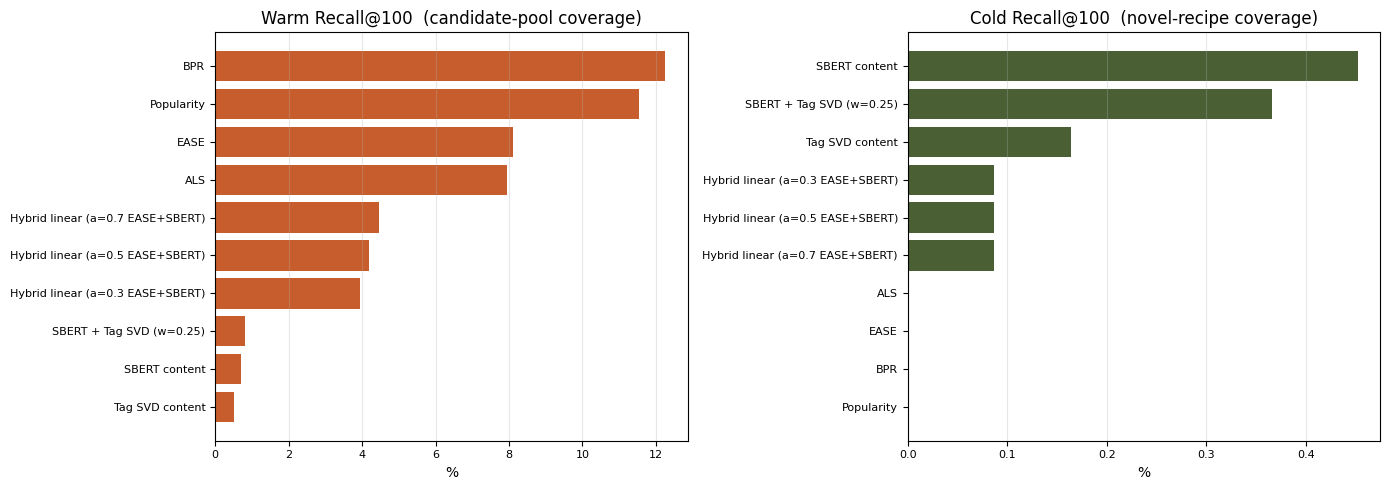

In [3]:
# Bar chart: the two pipeline-relevant numbers — warm@100 (relevance pool) and cold@100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
order_w = lb.sort_values("warm_r100", ascending=True)
axes[0].barh(order_w["model"], order_w["warm_r100"], color="#C75D2C")
axes[0].set_title("Warm Recall@100  (candidate-pool coverage)"); axes[0].set_xlabel("%")
order_c = lb.sort_values("cold_r100", ascending=True)
axes[1].barh(order_c["model"], order_c["cold_r100"], color="#4A6034")
axes[1].set_title("Cold Recall@100  (novel-recipe coverage)"); axes[1].set_xlabel("%")
for ax in axes:
    ax.tick_params(labelsize=8); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.savefig("data/processed/stage1_bars.png", dpi=150, bbox_inches="tight"); plt.show()

### Stage 1 findings

1. **BPR wins warm at the pool level** — Recall@100 = 12.25%, the only model beating
   Popularity (11.55%). (At @10 EASE edges it, but @100 is what feeds Stage 2 → BPR.)
2. **SBERT wins cold** — 0.087% @10, 0.452% @100 (~10× random). The only family with
   real signal on novel recipes.
3. **CF = 0 on cold, by construction** — Popularity / BPR / EASE / ALS. Expected.
4. **ALS is the weakest CF** (2.05 / 7.95 warm) — rounds out the menu, doesn't change picks.


## 5. Stage 1 conclusion: routing beats hybrids

We tried to get one model that's good at both tracks. **None beat just routing.**

| Approach | Warm @100 | Cold @100 | Verdict |
|---|---|---|---|
| BPR (CF) | **12.25** | 0 | warm specialist |
| SBERT (content) | 0.70 | **0.45** | cold specialist |
| EASE+TagSVD hybrid | — | 0 | TagSVD has no warm/cold signal → dilutes |
| EASE+SBERT hybrid | 4.45 | 0.087 | better, but **loses to BPR on warm AND SBERT on cold** |

A linear hybrid is "jack of both, master of neither." The architectural takeaway:
**route to the best specialist per query context** (BPR-warm, SBERT-cold) rather than
forcing one blended model. The α-blend belongs at *Stage 2 (constraints)*, not at
*Stage 1 (taste vs CF)* — where it doesn't help (the two signals are orthogonal here).


## 6. Stage 2 — the constraint reranker

Takes the Stage-1 pool (already diet-filtered) and ranks it:

$$\text{final}(u,r) = \alpha_t\,s_{taste} + \alpha_p\,s_{pantry} + \alpha_n\,s_{nutrition},\quad \alpha_t+\alpha_p+\alpha_n=1$$

- **s_taste** — Stage 1's relevance score, min-max normalized within the pool
- **s_pantry** — fraction of the recipe's *non-staple* ingredients the user has ([0,1])
- **s_nutrition** — Gaussian proximity of the recipe's macros to the user's targets ([0,1])
- **diet** — a HARD filter applied at Stage 1's exit (recipes failing it never reach Stage 2);
  Stage 2 still *reports* a diet badge for transparency but doesn't score on it

The (αₜ, αₚ, αₙ) weights are the dials the user (or the demo audience) turns.


## 7. The α-sweep — the X-factor (headline result)

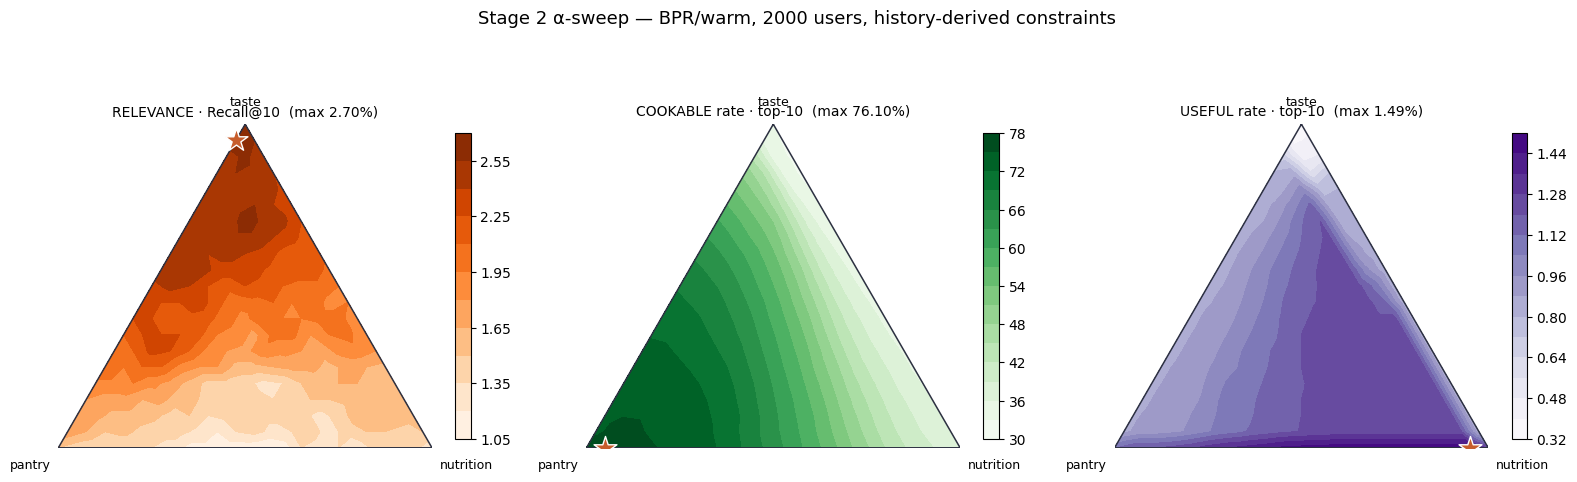

In [4]:
sw = pd.read_csv("data/processed/alpha_sweep_bpr_warm.csv")

_A = np.array([0.5, np.sqrt(3)/2]); _B = np.array([0.0,0.0]); _C = np.array([1.0,0.0])
def _xy(t,p,n):
    t,p,n = np.asarray(t),np.asarray(p),np.asarray(n)
    return t*_A[0]+p*_B[0]+n*_C[0], t*_A[1]+p*_B[1]+n*_C[1]
def ternary(ax, col, title, cmap):
    x,y = _xy(sw.alpha_taste, sw.alpha_pantry, sw.alpha_nutrition)
    z = sw[col].to_numpy()*100
    tcf = ax.tricontourf(mtri.Triangulation(x,y), z, levels=14, cmap=cmap)
    ax.plot([_A[0],_B[0],_C[0],_A[0]],[_A[1],_B[1],_C[1],_A[1]], color="#2D3142", lw=1.1)
    bi = sw[col].idxmax(); bx,by = _xy(sw.loc[bi].alpha_taste, sw.loc[bi].alpha_pantry, sw.loc[bi].alpha_nutrition)
    ax.scatter([bx],[by], marker="*", s=300, color="#C75D2C", edgecolor="white", zorder=5)
    ax.text(_A[0],_A[1]+0.05,"taste",ha="center",fontsize=9)
    ax.text(_B[0]-0.02,_B[1]-0.03,"pantry",ha="right",va="top",fontsize=9)
    ax.text(_C[0]+0.02,_C[1]-0.03,"nutrition",ha="left",va="top",fontsize=9)
    ax.set_title(f"{title}  (max {z.max():.2f}%)", fontsize=10); ax.axis("off"); ax.set_aspect("equal")
    plt.colorbar(tcf, ax=ax, shrink=0.7)

fig, axes = plt.subplots(1,3, figsize=(16,5))
ternary(axes[0],"recall@10","RELEVANCE · Recall@10","Oranges")
ternary(axes[1],"feasible_rate@10","COOKABLE rate · top-10","Greens")
ternary(axes[2],"useful_rate@10","USEFUL rate · top-10","Purples")
fig.suptitle("Stage 2 α-sweep — BPR/warm, 2000 users, history-derived constraints", y=1.02, fontsize=13)
plt.tight_layout(); plt.show()

In [5]:
def at(t,p,n):
    r = sw[(sw.alpha_taste==t)&(sw.alpha_pantry==p)&(sw.alpha_nutrition==n)]
    return r.iloc[0] if len(r) else None
rows=[]
for label,w in [("taste (1,0,0)",(1.0,0.0,0.0)),("pantry (0,1,0)",(0.0,1.0,0.0)),
                ("nutrition (0,0,1)",(0.0,0.0,1.0)),("balanced (.4,.3,.3)",(0.4,0.3,0.3))]:
    r=at(*w)
    if r is not None:
        rows.append({"weighting":label,"Recall@10 %":round(r["recall@10"]*100,3),
                     "cookable %":round(r["feasible_rate@10"]*100,1),
                     "useful %":round(r["useful_rate@10"]*100,2)})
pd.DataFrame(rows).set_index("weighting")

,Recall@10 %,cookable %,useful %
weighting,,,
"taste (1,0,0)",2.70,33.1,0.38
"pantry (0,1,0)",1.50,75.9,1.11
"nutrition (0,0,1)",1.25,36.6,1.24
"balanced (.4,.3,.3)",1.90,59.1,1.18


### The X-factor finding (this is the money slide)

- **Relevance peaks at the taste corner** (Recall@10 = 2.70%). To surface the user's exact
  next pick, weight Stage-1 taste.
- **Cookability peaks at the pantry corner** — the fraction of the top-10 a user can cook
  from their pantry jumps **33% → 76%** as you turn up αₚ. The strongest, clearest dial.
- **No corner wins everything.** Relevance and constraint-satisfaction trade off — the optimal
  α is a deliberate choice. That trade-off *is* the contribution.

**The trade-off is statistically significant on all three axes** (paired Wilcoxon, BPR/warm):

| Contrast | Δ | p-value |
|---|---|---|
| Cookable-rate: pantry vs taste | +42.75pp | 1.5×10⁻³¹⁰ |
| Relevance: taste vs pantry | +1.20pp | 0.0047 |
| Relevance: taste vs nutrition | +1.45pp | 0.0002 |
| Useful-rate: nutrition vs taste | +0.86pp | 3.6×10⁻²⁰ |

This is the project's most statistically robust result — note the contrast with Stage 1, where
no CF model significantly beats popularity. *Model choice barely matters; constraint weighting
matters a lot.* (Defense note: for relevance the marginal CIs overlap but the **paired** test is
significant — same users, only α changes — so the paired test is the correct lens.)

**Honest caveat:** the macro "near-rate" stays low everywhere (~2.5–3.9%) — hitting all 5 macros
within ±20% simultaneously is hard, so it caps the combined *useful* rate. Lead with
**cookable-rate** (33%→76%) as the clean demonstration; mention macros as the harder constraint.

## 8. End-to-end on a real persona (concrete example)

Runs the full pipeline for the **vegan_busy** persona to show the machinery end-to-end:
SBERT(taste seeds) → **diet hard-filter (vegan)** → Stage 2 rerank → top-5 with per-constraint
scores. First run loads SBERT (~30s, cached).

In [6]:
from src.data.loader import load_recipes, load_train_interactions
from src.models.sentence_bert import SentenceBERTRecommender
from src.reranker import Stage2Reranker, filter_by_diet

recipes = load_recipes(); recipes["id"]=recipes["id"].astype(np.int64)
recipes = recipes.set_index("id"); recipes.index.name="recipe_id"
train = load_train_interactions()
sbert = SentenceBERTRecommender(batch_size=256).fit(train, recipes_df=recipes.reset_index().rename(columns={"recipe_id":"id"}))

persona = json.load(open("data/personas/vegan_busy.json"))
# Stage 1: SBERT on the persona's taste seeds (overgenerate for the diet filter)
raw = sbert.recommend_for_seeds(persona["taste_seeds"], k=500)
pool = filter_by_diet(raw, persona["restrictions"], recipes, target_k=100)
taste_scores = {rid: 1.0/(r+1) for r,rid in enumerate(pool)}
print(f"persona={persona['id']}  restrictions={persona['restrictions']}")
print(f"Stage 1 raw 500 → {len(pool)} vegan-compliant candidates → Stage 2")

# Stage 2: balanced weights
rr = Stage2Reranker(alpha_taste=0.5, alpha_pantry=0.3, alpha_nutrition=0.2)
scored = rr.rerank(persona, pool, taste_scores, recipes, k=5, return_scores=True)
scored["name"] = scored["recipe_id"].map(lambda r: recipes.loc[r,"name"] if r in recipes.index else "?")
scored[["recipe_id","name","s_taste","s_pantry","s_nutrition","s_diet","final"]].round(3)

persona=vegan_busy  restrictions=['vegan']
Stage 1 raw 500 → 100 vegan-compliant candidates → Stage 2


,recipe_id,name,s_taste,s_pantry,s_nutrition,s_diet,final
0,99002,greens and garlic,1.000,0.200,0.005,1,0.561
1,98857,spinach with chickpeas,0.495,0.333,0.450,1,0.438
2,180771,open faced falafel burgers,0.158,0.154,0.421,1,0.209
3,308968,chickpea salad garbanzo bean salad,0.327,0.083,0.037,1,0.196
4,86561,veggie medley,0.074,0.300,0.327,1,0.192


Every recipe shown is vegan (diet filter), ranked by the blend of taste + pantry +
nutrition. Slide the α-weights (in the Streamlit app) and this ordering changes live —
that's the demo moment.

## 9. The live demo (Streamlit)

`uv run streamlit run streamlit_app.py` — launch a few minutes early (first load ~1–2 min).

- **Persona mode** — pick a pre-built character (fitness / vegan / family); their pantry,
  macros, restrictions pre-load and are editable.
- **Walk-in mode** — an audience member types a pantry + restriction live.
- **📷 Fridge photo / webcam** — Gemini Vision detects ingredients from an image and fills
  the pantry (optional; needs a local API key).
- **Three α sliders** — taste / pantry / macros, auto-normalised; recommendations + a
  per-recipe score breakdown update live. Recipe cards show ingredients colour-coded
  (✓ in pantry / staple / ✗ need to buy) and a novelty badge (🌱 cold item).

Demo arc: pick vegan_busy → show top-10 → expand a card (ingredients + macros) →
slide *pantry* up → watch the cookable recipes rise. That's the X-factor, live.


## 10. Limitations & honest framing (say these before they're asked)

- **Relevance numbers look small** (single-digit % Recall@10). That's normal for LOO on a
  231K-item catalogue, and it's the *Stage 1* ceiling — the user sees Stage 2's *reranked*
  top-10, not Stage 1's. Report @100 (pool coverage) alongside @10.
- **Macro constraint is hard** — all-5-macros ±20% rarely all hold; cookability is the
  cleaner constraint story.
- **CV (fridge photo) is an optional input path**, not a core model — it just fills the
  pantry. Was a dropped reach-goal we re-added for the demo.
- **Hybrids underperform routing** — a negative result, but a *useful* one: it justifies the
  routing architecture with evidence.
- **No live deployment** — course deliverable is the presentation + a cooked recipe, not a
  service.


## 11. Slide-by-slide mapping (for whoever builds the deck)

| Slide | Content | Source in this notebook / repo |
|---|---|---|
| Title / problem | §1 — competing-constraints pitch | §1 |
| Architecture | two-stage diagram + routing table | §2 |
| Data & eval | dual-track + Useful Recall definition | §3 |
| Stage 1 results | leaderboard table + the two bar charts | §4 (`stage1_bars.png`) |
| Stage 1 takeaway | "routing beats hybrids" table | §5 |
| Stage 2 method | the αₜ/αₚ/αₙ formula + constraint scorers | §6 |
| **X-factor (headline)** | the 3 ternary heatmaps + corners table | §7 (`alpha_sweep_ternary.png`) |
| Live demo | screenshots of the Streamlit app | §8–9 |
| Limitations | honest caveats | §10 |

**Pre-made image assets** (drop straight into slides):
- `data/processed/alpha_sweep_ternary.png` — the X-factor heatmaps
- `data/processed/stage1_bars.png` — Stage 1 coverage bars (generated by this notebook)

**Headline numbers to quote:**
- BPR warm Recall@100 = **12.25%** (best candidate pool)
- SBERT cold Recall@100 = **0.45%** (~10× random; CF = 0)
- Cookable-rate **33% → 76%** as pantry weight rises (the X-factor dial)


## 12. Pointers / reproduce

- **Leaderboard**: `docs/stage1_leaderboard.md` (+ `data/processed/stage1_leaderboard.csv`)
- **Models**: `src/models/` (popularity, bpr, ease, als, sentence_bert, tag_svd_content, hybrid_linear)
- **Stage 2**: `src/reranker/` (scores, combiner, filtering) · metric `src/eval/useful_recall.py`
- **α-sweep**: `src/eval/alpha_sweep.py` · `notebooks/alpha_sweep.ipynb` · CSV in `data/processed/`
- **Per-model notebooks**: `notebooks/sentence_bert_smoke.ipynb`, `tag_svd_smoke.ipynb`, `stage2_demo.ipynb`
- **Demo app**: `streamlit_app.py`
- **Eval harness**: `src/eval/harness.py` (`docs/eval_harness_usage.md`)
- **Locked decisions**: `docs/data_decisions.md`
